# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Exam Performance factors Dataset](https://www.kaggle.com/datasets/jimarahman/student-exam-performance-dataset-analysis/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

/kaggle/input/datasets/jimarahman/student-exam-performance-dataset-analysis/StudentPerformanceFactors.csv


## Import CSV And convert to DataFrame

In [48]:
df = pd.read_csv('StudentPerformanceFactors.csv')

# Preprocessing

## Frist five row

In [49]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## last Five row

In [50]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


## Shape of our dataset

In [51]:
df.shape

(6607, 20)

## List out all columns

In [52]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

## Datatype of each columns

In [53]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

## Information of all Columns

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## Check Null Value

In [55]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## fill categorical nulls with mode

In [56]:
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])

## Check Dupicate Value

In [57]:
df.duplicated().sum()

np.int64(0)

## Summary

In [58]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# EDA

In [59]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

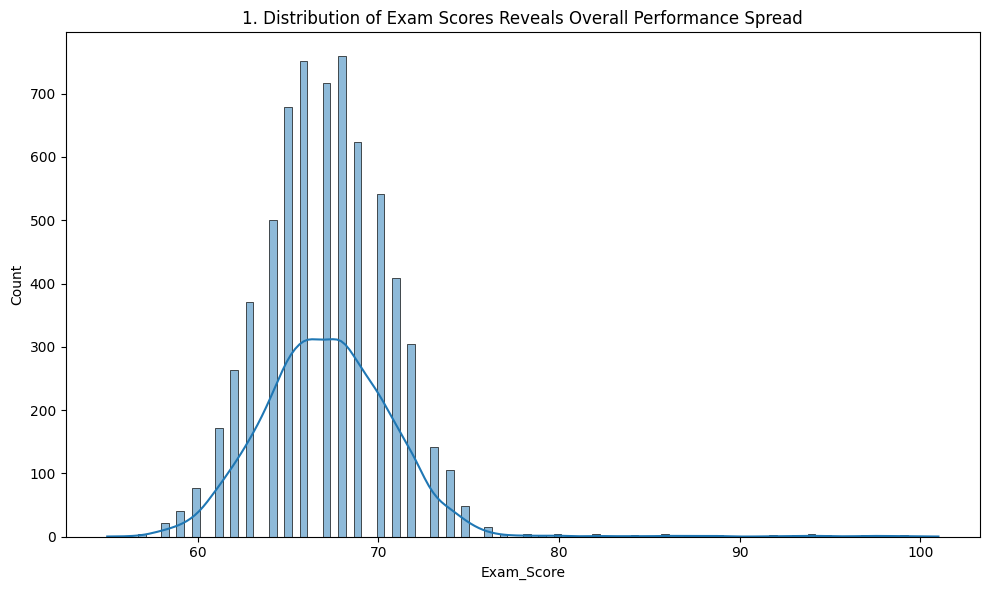

In [60]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Exam_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Exam Scores Reveals Overall Performance Spread')
show_fig()
plot_no += 1

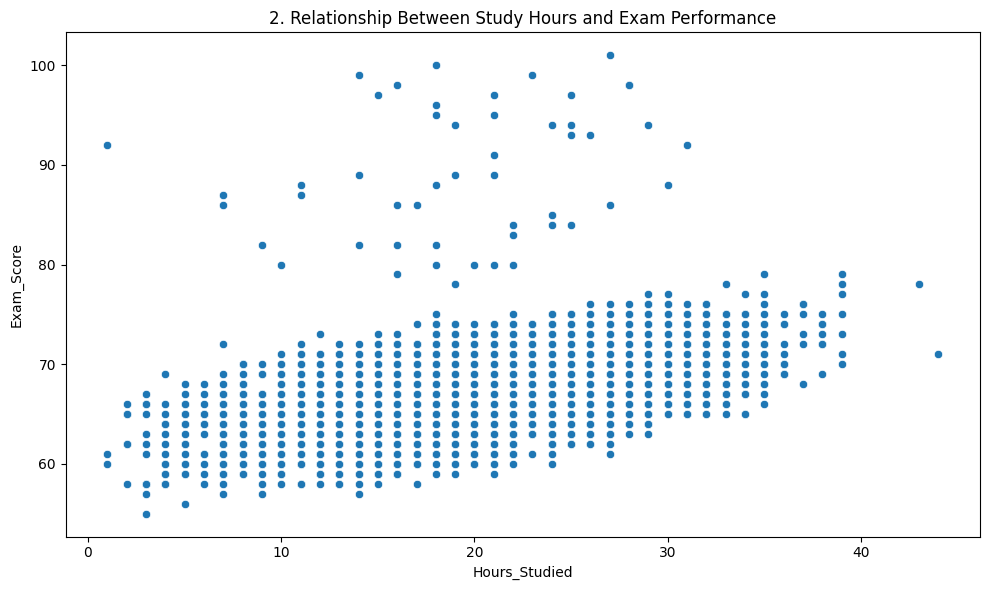

In [61]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Hours_Studied'], y=df['Exam_Score'])
plt.title(f'{plot_no}. Relationship Between Study Hours and Exam Performance')
show_fig()
plot_no += 1

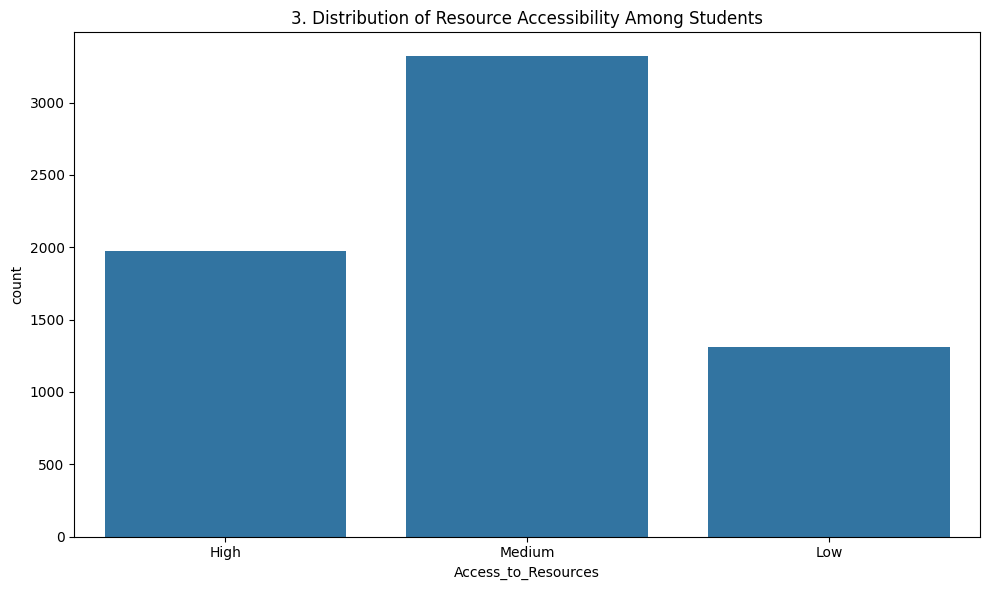

In [62]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x=df['Access_to_Resources'])
plt.title(f'{plot_no}. Distribution of Resource Accessibility Among Students')
show_fig()
plot_no += 1

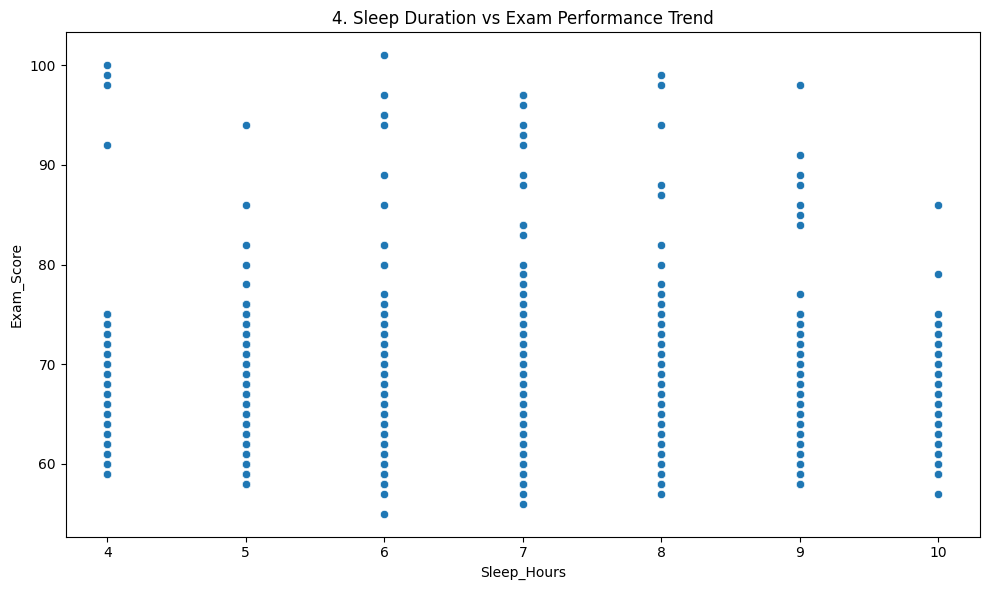

In [63]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Sleep_Hours'], y=df['Exam_Score'])
plt.title(f'{plot_no}. Sleep Duration vs Exam Performance Trend')
show_fig()
plot_no += 1

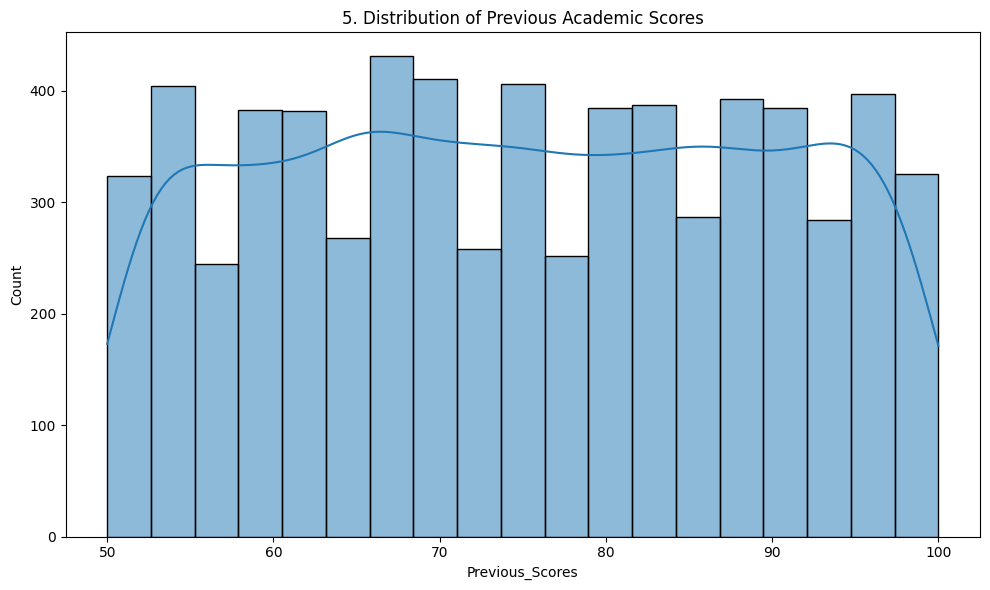

In [64]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Previous_Scores'], kde=True)
plt.title(f'{plot_no}. Distribution of Previous Academic Scores')
show_fig()
plot_no += 1

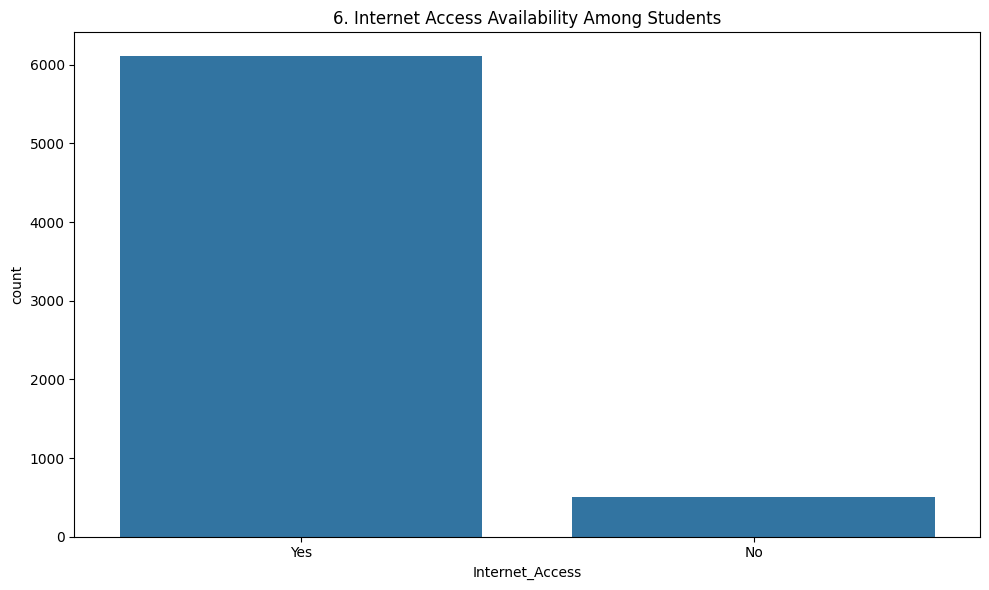

In [65]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x=df['Internet_Access'])
plt.title(f'{plot_no}. Internet Access Availability Among Students')
show_fig()
plot_no += 1

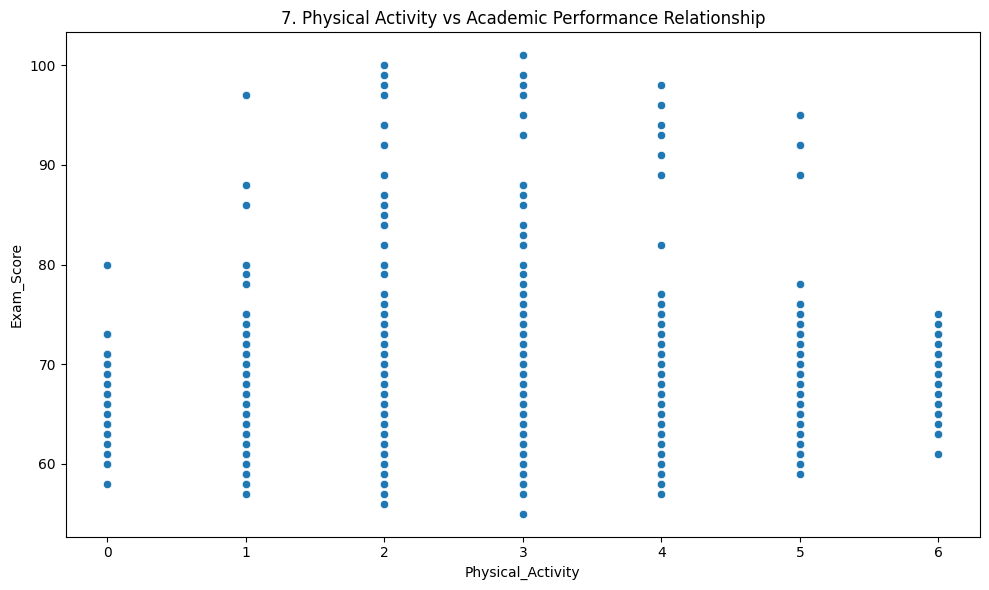

In [66]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Physical_Activity'], y=df['Exam_Score'])
plt.title(f'{plot_no}. Physical Activity vs Academic Performance Relationship')
show_fig()
plot_no += 1

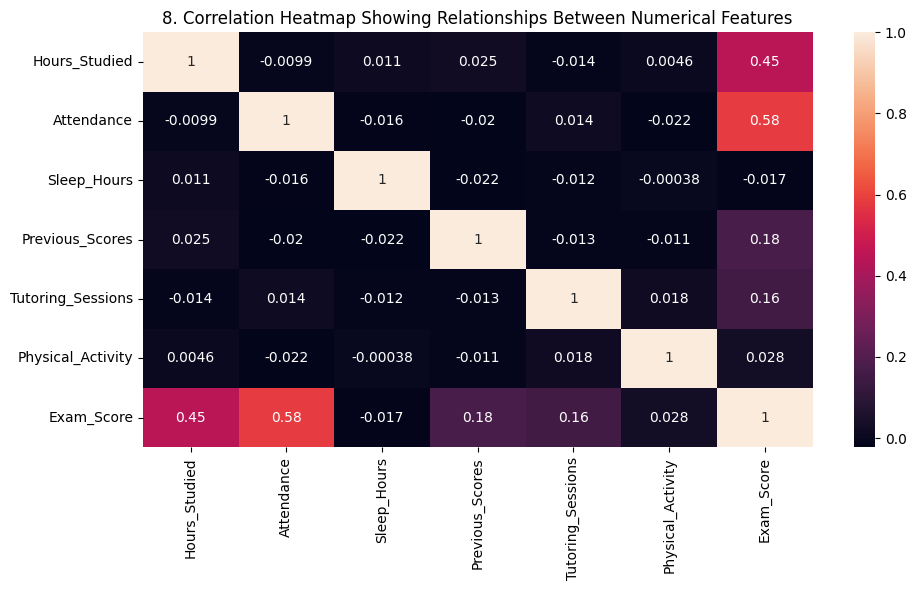

In [67]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap Showing Relationships Between Numerical Features')
show_fig()
plot_no += 1

# Model Training

## select only numerical features

In [69]:
X = df[['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity']]
y = df['Exam_Score']

## split data into train and test

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [71]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train linear regression model

In [72]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## make predictions

In [73]:
y_pred = model.predict(X_test)

## print model accuracy

In [74]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6416391364668392


## plot actual vs predicted values

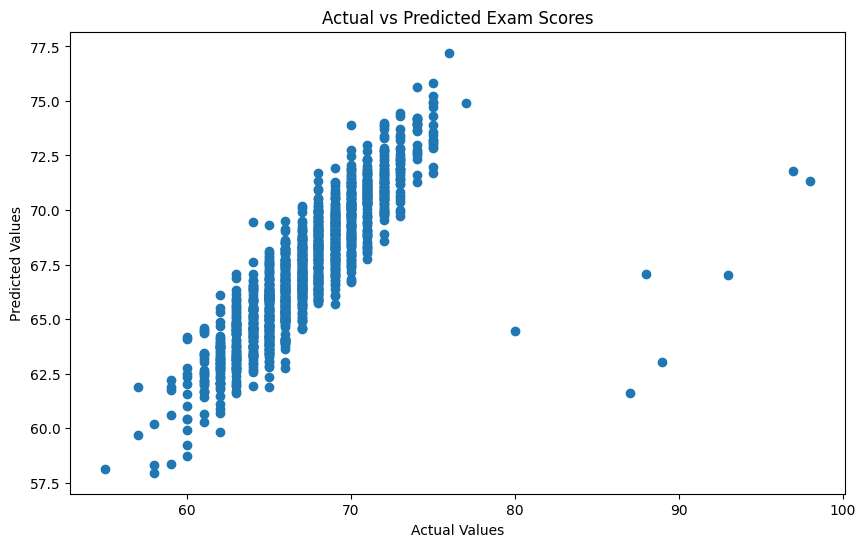

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Exam Scores")
plt.show()